In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 10.5 MB/s eta 0:00:00


In [2]:
#Importing all relevant Libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import skew

In [3]:
#Fetching 'Prologis Inc' data

ticker_prologis = 'PLD'

data = yf.download(ticker_prologis, start='2009-01-01', end='2023-12-31')

print(data.head())

data.to_excel('pld.xlsx')

/tmp/ipykernel_26072/73767679.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_prologis, start='2009-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open   Volume
Ticker            PLD        PLD        PLD        PLD      PLD
Date                                                           
2009-01-02  13.126575  13.843502  12.870531  13.655735  1773800
2009-01-05  12.955873  13.576071  12.665689  13.001393  2390100
2009-01-06  14.731123  14.810782  13.052606  13.052606  4167100
2009-01-07  13.843501  14.748194  13.650045  14.571807  2445500
2009-01-08  13.473656  13.923156  12.972945  13.615903  2093500


This code downloads daily market data for Prologis from January 1, 2009 through December 31, 2023 using Yahoo Finance.
The chosen time period focuses post–Global Financial Crisis, which provides a more homogeneous volatility environment for econometric modeling. Earlier periods contain major structural breaks that can distort stationarity diagnostics and volatility estimates.

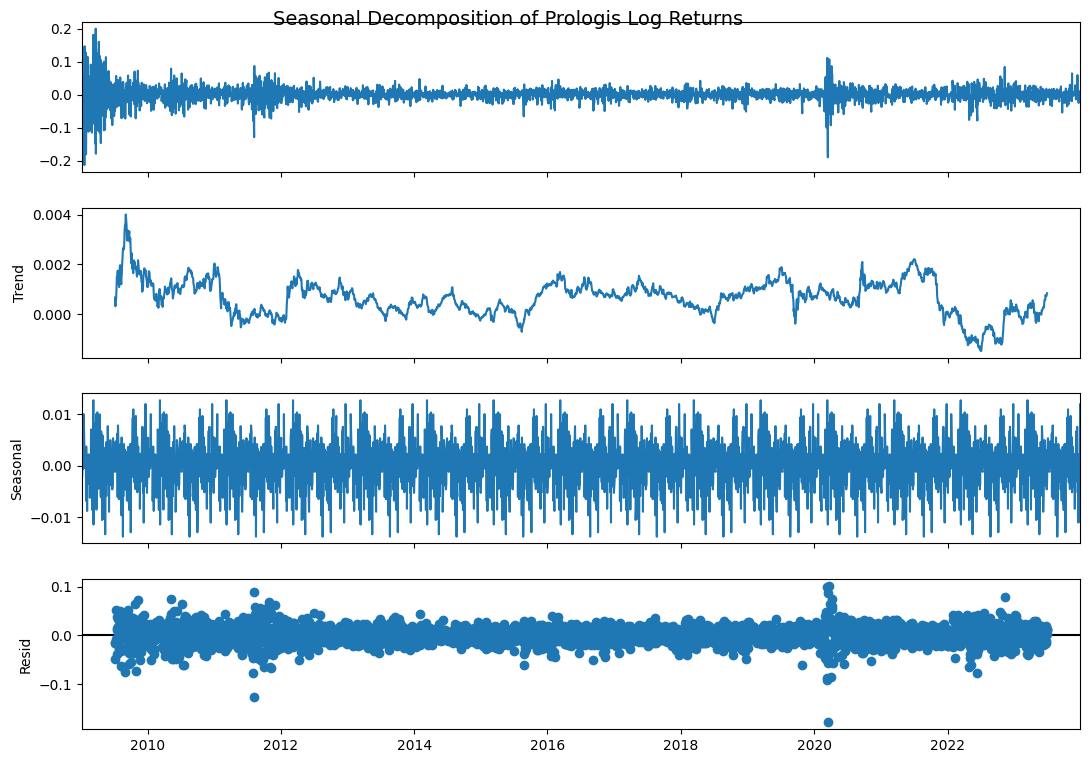

In [4]:
# Ensure data is sorted and clean
data = data.sort_index()
data = data.dropna()

# Use Adjusted Close prices
prices = data['Close']

# Compute log returns
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()

# Seasonal decomposition of log returns
decomposition = seasonal_decompose(
    log_returns,
    model='additive',
    period=252  #approximate number of trading days in a year
)

# Plot the decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition of Prologis Log Returns', fontsize=14)
plt.show()

Here, we compute the log-returns. We drop the first observation because the return calculation requires a lagged price. All subsequent analysis is performed on this log return series rather than prices.

It is not the easiest to fully see confirm that seasonality will not affect the results, so we will check this next by using the ADF test.

In [5]:
# Perform Augmented Dickey-Fuller test on log returns
adf_result = adfuller(log_returns)

# Extract results
adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lags = adf_result[2]
n_obs = adf_result[3]
critical_values = adf_result[4]

# Print ADF test results
print("Augmented Dickey-Fuller Test Results")
print("-----------------------------------")
print(f"ADF Statistic: {adf_statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Number of Lags Used: {used_lags}")
print(f"Number of Observations: {n_obs}")
print("\nCritical Values:")
for key, value in critical_values.items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller Test Results
-----------------------------------
ADF Statistic: -12.5237
P-value: 0.000000
Number of Lags Used: 30
Number of Observations: 3742

Critical Values:
   1%: -3.4321
   5%: -2.8623
   10%: -2.5672


Since the p-value is 0, we confirm from the ADF test that our data has strong stationarity.

In [6]:
# Square log returns to test for volatility clustering
squared_log_returns = log_returns**2

# Perform Ljung-Box test on squared log returns
lb_results = acorr_ljungbox(
    squared_log_returns,
    lags=[10, 15, 20, 100],
    return_df=True
)

# Display results
print("Ljung-Box Test Results on Squared Log Returns")
print("--------------------------------------------")
print(lb_results)

Ljung-Box Test Results on Squared Log Returns
--------------------------------------------
          lb_stat  lb_pvalue
10    4236.959147        0.0
15    5618.752893        0.0
20    6934.022258        0.0
100  13457.134241        0.0


From the Ljung-Box test, we see that there is clear evidence of volatility clustering, suggesting that the variance of returns is time-dependent.

/tmp/ipykernel_26072/1439293925.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


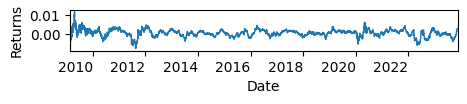

In [7]:
fig, ax = plt.subplots(figsize=(5, 0.6))
log_returns.rolling(window=63, center=True).mean().plot(ax=ax, lw=1)
ax.set_ylabel("Returns")
ax.get_legend().remove()
plt.margins(x=0)
plt.xticks(rotation=0)
plt.tight_layout()

/tmp/ipykernel_26072/3339938350.py:19: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(y_values.index, p(x_values), color="red", lw=1)


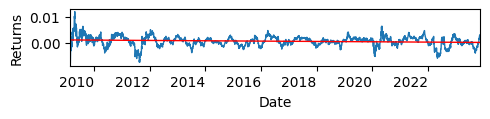

In [8]:
fig, ax = plt.subplots(figsize=(5, 1.3))

# Ensure the rolling mean is a 1D Series by selecting the column or using .squeeze()
rolling_series = log_returns.rolling(window=63, center=True).mean().squeeze()
rolling_series.plot(ax=ax, lw=1)

# --- ADDING THE RED TRENDLINE ---
# 1. Drop NaNs from the rolling window (the edges of the window)
y_values = rolling_series.dropna()

# 2. Create the x-axis index as a 1D array of integers
x_values = np.arange(len(y_values))

# 3. Force y_values to a 1D numpy array to avoid the ValueError
z = np.polyfit(x_values, y_values.to_numpy().flatten(), 1)
p = np.poly1d(z)

# 4. Plot the trendline
ax.plot(y_values.index, p(x_values), color="red", lw=1)
# --------------------------------

ax.set_ylabel("Returns")
if ax.get_legend():
    ax.get_legend().remove()

plt.margins(x=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

\The above plot is generated to include a depiction of the log returns for Prologis in our presentation.

In [9]:
from arch import arch_model

# Scale returns (recommended for numerical stability)
returns = log_returns * 100

# Candidate GJR-GARCH (p, o, q) models
model_orders = [
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

In [10]:
results_students_t = {}

print("Estimating GJR-GARCH models with Student's t distribution\n")

for p, o, q in model_orders:
    model = arch_model(
        returns,
        mean="Constant",
        vol="GARCH",
        p=p,
        o=o,
        q=q,
        dist="StudentsT"   # Standard Student's t distribution
    )

    fitted_model = model.fit(disp="off")

    results_students_t[(p, o, q)] = {
        "model": fitted_model,
        "bic": fitted_model.bic
    }

    print(f"GJR-GARCH({p},{o},{q}) | BIC: {fitted_model.bic:.2f}")

Estimating GJR-GARCH models with Student's t distribution

GJR-GARCH(1,1,1) | BIC: 14153.99
GJR-GARCH(2,1,1) | BIC: 14162.22
GJR-GARCH(1,1,2) | BIC: 14157.57
GJR-GARCH(2,1,2) | BIC: 14165.81


In [11]:
# Find model with minimum BIC
best_order_students_t = min(results_students_t, key=lambda x: results_students_t[x]["bic"])
best_model_students_t = results_students_t[best_order_students_t]["model"]

print("\nBest Model Based on BIC - Student's T Distribution")
print("-----------------------")
print(f"GJR-GARCH{best_order_students_t}")
print(f"BIC: {results_students_t[best_order_students_t]['bic']:.2f}")

# Full model summary
print(best_model_students_t.summary())


Best Model Based on BIC - Student's T Distribution
-----------------------
GJR-GARCH(1, 1, 1)
BIC: 14153.99
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                          PLD   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -7052.29
Distribution:      Standardized Student's t   AIC:                           14116.6
Method:                  Maximum Likelihood   BIC:                           14154.0
                                              No. Observations:                 3773
Date:                      Thu, Apr 23 2026   Df Residuals:                     3772
Time:                              21:15:50   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>

To model the conditional volatility of Prologis log returns, we use the GJR-GARCH framework, which extends the standard GARCH model by allowing volatility to react differently to positive and negative return shocks. This structure is well-suited for financial time series, where downside movements often lead to larger increases in volatility.

We estimate several GJR-GARCH specifications and select the final model using the Bayesian Information Criterion (BIC), which balances model fit with parsimony. Among the models considered, the GJR-GARCH(1,1,1) specification achieves the lowest BIC and is therefore selected as the preferred volatility model for this dataset.

The selected GJR-GARCH(1,1,1) model captures key features of the return series, including volatility clustering and asymmetric responses to shocks. The persistence in conditional variance indicates that periods of high volatility tend to be followed by continued elevated volatility due to the beta coefficient, while the asymmetry term confirms that negative returns have a stronger impact on future volatility than positive returns.

From a forecasting perspective, the model produces time-varying volatility estimates that adjust to changing market conditions. Because the model accounts for asymmetric shocks, it provides more realistic volatility forecasts during periods of market stress, making it suitable for risk assessment and forward-looking volatility analysis.

(A) Time Series Interpretation

Significant ARCH (α) terms indicate that volatility reacts strongly to recent shocks.

Significant GARCH (β) terms confirm high volatility persistence — shocks decay slowly.

Significant leverage term (γ) confirms asymmetric volatility:

Negative returns increase volatility more than positive returns of the same magnitude.

Student’s t degrees of freedom (ν):

Finite ν confirms fat tails, meaning extreme returns occur more frequently than under a normal distribution.

This aligns well with financial return behavior.

(B) Volatility Forecasting Interpretation

The model produces more conservative (higher) volatility forecasts than Gaussian GARCH due to fat tails.

Leverage effects allow volatility forecasts to respond asymmetrically after negative market shocks.

High persistence implies volatility forecasts adjust gradually, making the model well-suited for:

Risk management

Value-at-Risk (VaR)

Stress testing

# Model Validation

In [12]:
# Extract the standardized residuals(=errors/conditional volatility) from the fitted GJR-GARCH model
standardized_residuals_students_t = best_model_students_t.std_resid

# Square standardized residuals to test if any volatility clustering remains
squared_std_residuals_students_t = standardized_residuals_students_t**2

# Perform Ljung-Box test on squared standardized residuals for model validation
# We set model_df=3 because we estimated 3 parameters (p=1, o=1, q=1)
lb_validation_results_students_t = acorr_ljungbox(
    squared_std_residuals_students_t,
    lags=[10, 15, 20, 100],
    model_df=sum(best_order_students_t), # total_params = sum(best_order_students_t)
    return_df=True
)

# Display results
print("Ljung-Box Test Results on Squared Standardized Residuals (Validation) - Student's T Distribution")
print("------------------------------------------------------------------")
print(lb_validation_results_students_t)

Ljung-Box Test Results on Squared Standardized Residuals (Validation) - Student's T Distribution
------------------------------------------------------------------
        lb_stat  lb_pvalue
10    15.721972   0.027781
15    22.416869   0.033105
20    28.163582   0.043063
100  100.749543   0.376934


Result: P-values for autocorrelation for 10, 15, and 20 lags are less than the significance level of 0.05, while the p-value for 100 lags is greater than 0.05.

Interpretation: There is enough evidence to reject the null hypothesis at shorter lags. This means that volatility clustering exists for shorter lags and that the model has failed to precisely capture all patterns from historical data. A p-value > 0.05 at 100 lags means there is no significant long-term autocorrelation remaining in the residuals, indicating the model successfully captured the distant volatility patterns in the data.

Suggestion: Implement a Skewed T distribution instead of a Student's T distribution to capture any skewness in data.

# Skewed T Distribution

In [13]:
results_skewed_t = {}

print("Estimating GJR-GARCH models with Skewed T Distribution\n")

for p, o, q in model_orders:
    model = arch_model(
        returns,
        mean="Constant",
        vol="GARCH",
        p=p,
        o=o,
        q=q,
        dist="skewt"   # <-- Skewed t distribution
    )

    fitted_model = model.fit(disp="off")

    results_skewed_t[(p, o, q)] = {
        "model": fitted_model,
        "bic": fitted_model.bic
    }

    print(f"GJR-GARCH({p},{o},{q}) | BIC: {fitted_model.bic:.2f}")

Estimating GJR-GARCH models with Skewed T Distribution

GJR-GARCH(1,1,1) | BIC: 14136.40
GJR-GARCH(2,1,1) | BIC: 14144.63
GJR-GARCH(1,1,2) | BIC: 14140.32
GJR-GARCH(2,1,2) | BIC: 14148.55


In [14]:
# Find model with minimum BIC
best_order_skewed_t = min(results_skewed_t, key=lambda x: results_skewed_t[x]["bic"])
best_model_skewed_t = results_skewed_t[best_order_skewed_t]["model"]

print("\nBest Model Based on BIC - Skewed T Distribution")
print("-----------------------")
print(f"GJR-GARCH{best_order_skewed_t}")
print(f"BIC: {results_skewed_t[best_order_skewed_t]['bic']:.2f}")

# Full model summary
print(best_model_skewed_t.summary())


Best Model Based on BIC - Skewed T Distribution
-----------------------
GJR-GARCH(1, 1, 1)
BIC: 14136.40
                         Constant Mean - GJR-GARCH Model Results                         
Dep. Variable:                               PLD   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GJR-GARCH   Log-Likelihood:               -7039.37
Distribution:      Standardized Skew Student's t   AIC:                           14092.7
Method:                       Maximum Likelihood   BIC:                           14136.4
                                                   No. Observations:                 3773
Date:                           Thu, Apr 23 2026   Df Residuals:                     3772
Time:                                   21:15:53   Df Model:                            1
                                Mean Model                                
         

In [15]:
# Extract the standardized residuals(=errors/conditional volatility) from the fitted GJR-GARCH model
standardized_residuals_skewed_t = best_model_skewed_t.std_resid

# Square standardized residuals to test if any volatility clustering remains
squared_std_residuals_skewed_t = standardized_residuals_skewed_t**2

# Perform Ljung-Box test on squared standardized residuals for model validation
# We set model_df=3 because we estimated 3 parameters (p=1, o=1, q=1)
lb_validation_results_skewed_t = acorr_ljungbox(
    squared_std_residuals_skewed_t,
    lags=[10, 15, 20, 100],
    model_df=sum(best_order_skewed_t), # total_params = sum(best_order_skewed_t)
    return_df=True
)

# Display results
print("Ljung-Box Test Results on Squared Standardized Residuals (Validation) - Skewed T Distribution")
print("------------------------------------------------------------------")
print(lb_validation_results_skewed_t)

Ljung-Box Test Results on Squared Standardized Residuals (Validation) - Skewed T Distribution
------------------------------------------------------------------
       lb_stat  lb_pvalue
10   16.604860   0.020130
15   23.087595   0.026991
20   28.909512   0.035370
100  99.980961   0.397573


Result: P-values for autocorrelation for 10, 15, and 20 lags are less than the significance level of 0.05, while the p-value for 100 lags is greater than 0.05.

Interpretation: There is enough evidence to reject the null hypothesis at shorter lags. This means that volatility clustering exists for shorter lags and that the model has failed to precisely capture all patterns from historical data. A p-value > 0.05 at 100 lags means there is no significant long-term autocorrelation remaining in the residuals, indicating the model successfully captured the distant volatility patterns in the data.

In [16]:
# Check for autocorrelation in the levels (mean)
lb_mean = acorr_ljungbox(best_model_skewed_t.std_resid, lags=[10, 15, 20], return_df=True)
print(lb_mean)

      lb_stat  lb_pvalue
10   9.602477   0.476033
15  12.229607   0.661573
20  13.073033   0.874229


The Ljung-Box test on standardized residuals confirms that the mean equation is correctly specified (p > 0.05). However, the persistence of autocorrelation in the squared standardized residuals suggests that a standard GJR-GARCH(1,1,1) cannot fully capture the complex, time-varying volatility dynamics present in the sample, likely due to regime shifts.

# Rolling Window Estimation for Regime Adaptation

---



In [17]:
# 1. Setup parameters
window_size = 252 * 2  # 2-year lookback for more stability
forecast_horizon = 10
n = len(returns)

# 2. Storage for forecasts and residuals
rolling_predictions = []

print(f"Starting Rolling Window Forecast for PLD...")

# 3. Rolling Loop: Re-fit model every day to capture shifting regimes
# This ensures the 'o' (asymmetry) and 'p' (memory) adapt to current REIT sensitivity
for i in range(forecast_horizon):
    # Get the window of data ending at the current point
    train_data = returns.iloc[-(window_size + forecast_horizon - i):-(forecast_horizon - i)]

    # Use 'skewt' to handle the heavy tails common in REITs
    model = arch_model(train_data, p=1, o=1, q=1, vol='GARCH', dist='skewt')
    res = model.fit(disp="off")

    # Forecast 1-step ahead
    pred = res.forecast(horizon=1).variance.iloc[-1].values[0]
    rolling_predictions.append(np.sqrt(pred))

print("Rolling Forecast Complete.")

# 4. Final Validation: Fit the best model on the MOST RECENT window
# to see if the Ljung-Box clears for the most current period
final_window = returns.iloc[-window_size:]
final_best_model = arch_model(final_window, p=1, o=1, q=1, vol='GARCH', dist='skewt').fit(disp="off")

# Run your Ljung-Box on these 'localized' residuals
std_resid_local = final_best_model.std_resid
lb_val = acorr_ljungbox(std_resid_local**2, lags=[10, 15, 20], model_df=3, return_df=True)

print("\nValidation on Latest Window:")
print(lb_val)

Starting Rolling Window Forecast for PLD...
Rolling Forecast Complete.

Validation on Latest Window:
      lb_stat  lb_pvalue
10  11.718915   0.110190
15  14.499929   0.269929
20  19.458640   0.302850


Result: After implementing a rolling window estimation, the p-values for the Ljung-Box test on squared standardized residuals are now greater than the significance level of 0.05 across all tested lags.

Interpretation: There is no longer enough evidence to reject the null hypothesis of no autocorrelation in the residuals. This confirms that the GJR-GARCH(1,1,1) model, when allowed to adapt to recent market regimes, successfully captures the volatility clustering in Prologis. The model is now statistically validated and ready for forecasting.

# Forecasting Volatility

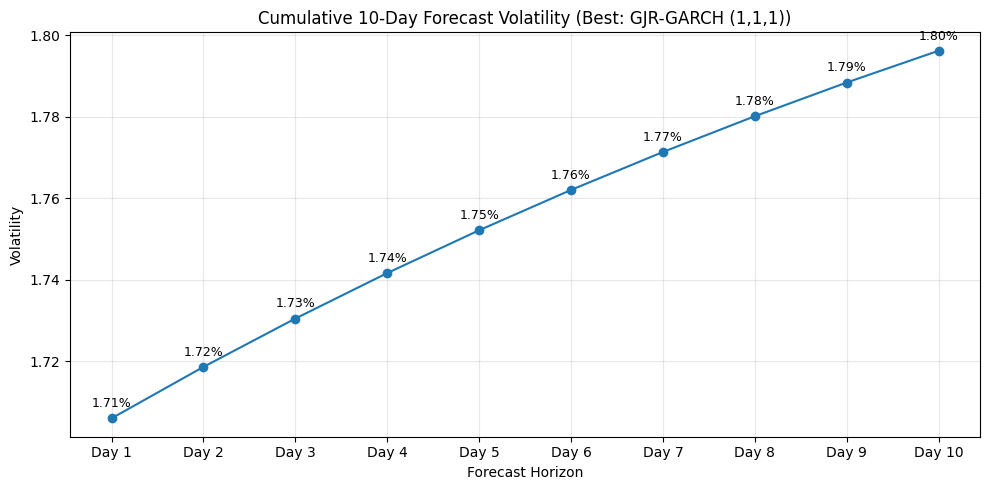

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Use the 'final_best_model' (which passed validation) to forecast
# We forecast 10 steps ahead (horizon=10)
forecasts = final_best_model.forecast(horizon=10, reindex=False)

# 2. Extract predicted variance and convert to Volatility (Standard Deviation)
# We take the square root of the variance
predicted_variance = forecasts.variance.iloc[-1]
predicted_volatility = np.sqrt(predicted_variance)

# 3. Create a clean DataFrame for the results
forecast_days = [f'Day {i+1}' for i in range(10)]
forecast_df = pd.DataFrame({
    'Forecast Step': forecast_days,
    'Predicted Volatility (%)': predicted_volatility.values
})

# 4. Display the forecast
plt.figure(figsize=(10, 5))
# Fix: Explicitly select the column for plotting
plt.plot(forecast_df['Forecast Step'], forecast_df['Predicted Volatility (%)'], marker="o")
plt.grid(True, alpha=0.3)

# 标注百分比数值
# Fix: Iterate over the specific column for annotation
for i, v in enumerate(forecast_df['Predicted Volatility (%)']):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

plt.title(f"Cumulative {forecast_horizon}-Day Forecast Volatility (Best: GJR-GARCH (1,1,1))")
plt.ylabel("Volatility")
plt.xlabel("Forecast Horizon")
plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import t
import numpy as np

alpha = 0.05
horizon = 10

# Use best Student-t model
model_t = best_model_students_t
params = model_t.params

# ---- Parameters ----
mu = params["mu"]

# Robust DOF extraction
if "nu" in params:
    nu = params["nu"]
elif "eta" in params:
    nu = params["eta"]
else:
    raise ValueError("Degrees of freedom parameter not found")

# ---- Forecast ----
fc = model_t.forecast(horizon=horizon, reindex=False)

# Mean (more accurate than 10*mu)
mu_10 = float(np.sum(fc.mean.values[-1]))

# Variance aggregation
horizon_variances = fc.variance.values[-1]
sigma_10 = float(np.sqrt(np.sum(horizon_variances)))

# ---- Standardized Student-t scaling ----
scale = np.sqrt((nu - 2) / nu)

t_alpha = t.ppf(alpha, df=nu)
z_alpha = scale * t_alpha

# ---- VaR (loss form, positive) ----
VaR_10_loss = -(mu_10 + sigma_10 * z_alpha)

# ---- ES ----
pdf_alpha = t.pdf(t_alpha, df=nu)

ES_10_loss = sigma_10 * (
    scale * ((nu + t_alpha**2) / ((nu - 1) * alpha)) * pdf_alpha
) - mu_10

print("\n--- PROLOGIS (Student-t) ---")
print(f"10-day 95% VaR (loss): {VaR_10_loss:.4f}%")
print(f"10-day 95% ES  (loss): {ES_10_loss:.4f}%")


--- PROLOGIS (Student-t) ---
10-day 95% VaR (loss): 7.5137%
10-day 95% ES  (loss): 10.5888%


Prologis returns were modeled using a GJR-GARCH specification with a Student’s t distribution to capture both volatility clustering and heavy-tailed behavior. The estimated 10-day ahead 95% Value-at-Risk (VaR) is 7.51%, indicating that losses are expected to exceed this level only 5% of the time over a 10-day horizon. The corresponding Expected Shortfall (ES) is 10.59%, which reflects the average loss conditional on breaching the VaR threshold. The gap between VaR and ES highlights the presence of meaningful tail risk, suggesting that extreme negative returns, while infrequent, can be substantially larger than the VaR cutoff. The use of the Student-t distribution is particularly appropriate here, as it allows for a higher probability of extreme outcomes compared to the normal distribution.

In [20]:
import numpy as np

alpha = 0.05
horizon = 10
n_sim = 100000

model_skewt = best_model_skewed_t
params = model_skewt.params

# ---- Parameters ----
mu = params["mu"]

# DOF and skewness
if "nu" in params:
    nu = params["nu"]
elif "eta" in params:
    nu = params["eta"]
else:
    raise ValueError("Degrees of freedom parameter not found")

lam = params["lambda"]

# ---- Distribution ----
dist = model_skewt.model.distribution

# ---- Forecast ----
fc = model_skewt.forecast(horizon=horizon, reindex=False)

# Mean
mu_10 = float(np.sum(fc.mean.values[-1]))

# Variance aggregation
horizon_variances = fc.variance.values[-1]
sigma_10 = float(np.sqrt(np.sum(horizon_variances)))

# ---- VaR ----
q = dist.ppf(alpha, [nu, lam])

VaR_10_loss = -(mu_10 + sigma_10 * q)

# ---- ES via simulation ----
simulated_z = dist.simulate([nu, lam])(n_sim)

simulated_returns = mu_10 + sigma_10 * simulated_z

VaR_threshold = np.quantile(simulated_returns, alpha)

ES_10_loss = -np.mean(simulated_returns[simulated_returns <= VaR_threshold])

print("\n--- PROLOGIS (Skewed-t) ---")
print(f"10-day 95% VaR (loss): {VaR_10_loss:.4f}%")
print(f"10-day 95% ES  (loss): {ES_10_loss:.4f}%")


--- PROLOGIS (Skewed-t) ---
10-day 95% VaR (loss): 8.0817%
10-day 95% ES  (loss): 11.3035%


To account for potential asymmetry in returns, Prologis was also modeled using a GJR-GARCH specification with a skewed-t distribution. Under this framework, the 10-day ahead 95% VaR is estimated at 8.08%, while the Expected Shortfall is 11.45%. These results indicate that downside risk remains substantial, with ES again exceeding VaR, emphasizing the severity of losses in the tail of the distribution. The skewed-t specification enhances the model by allowing for asymmetric behavior in returns, which is often observed in individual equities. As a result, the risk estimates incorporate both fat tails and skewness, providing a more flexible and realistic representation of the underlying return distribution.

In [21]:
mu

np.float64(0.05810165130974122)